In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [15]:
df= pd.read_excel( "heart_disease.xlsx", sheet_name="Heart_disease" )

In [16]:
df.shape

(908, 13)

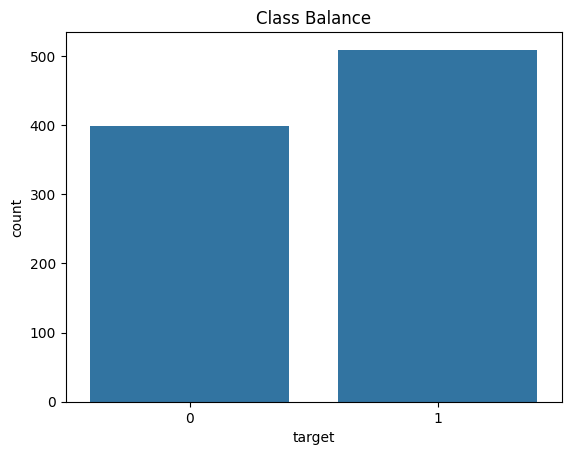

In [17]:
df["target"] = (df["num"] > 0).astype(int)
sns.countplot(data=df, x="target")
plt.title("Class Balance")
plt.show()

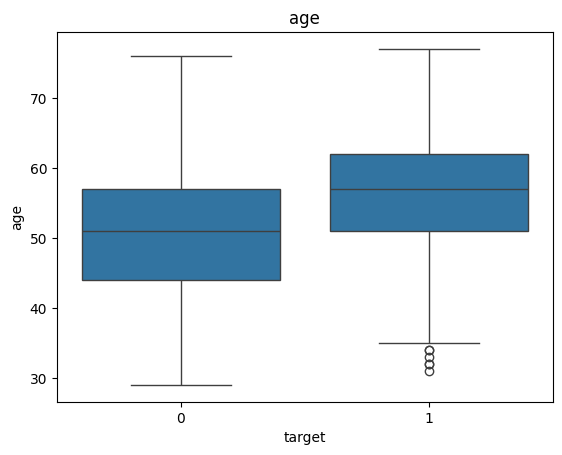

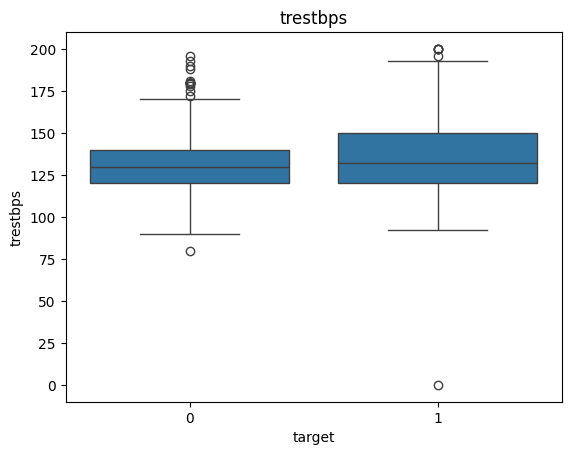

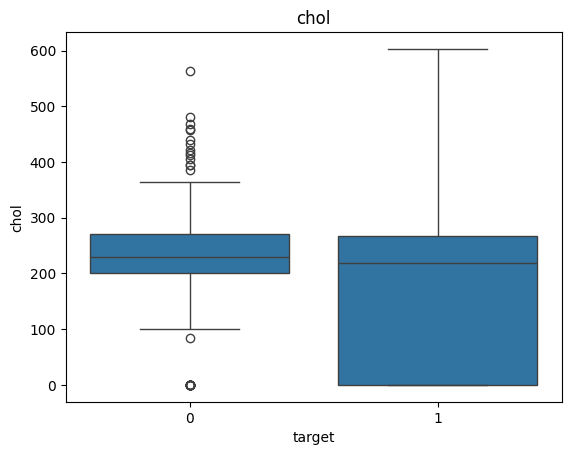

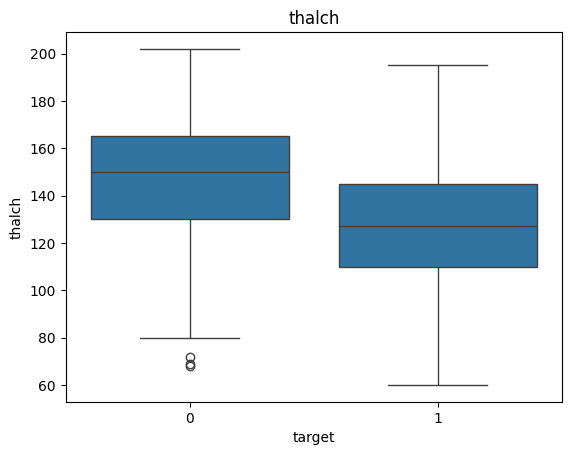

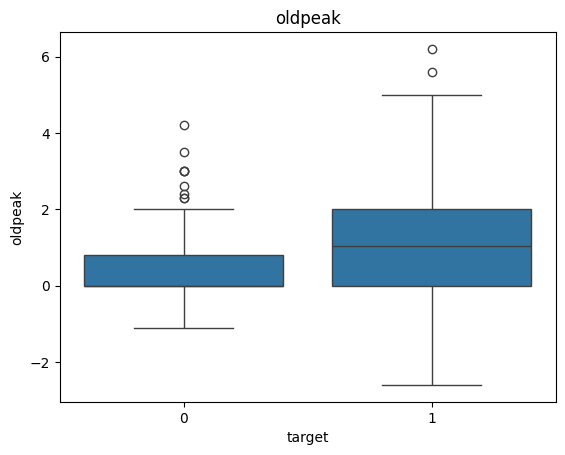

In [18]:
num_cols = ["age", "trestbps", "chol", "thalch", "oldpeak"]
for col in num_cols:
    plt.figure()
    sns.boxplot(data=df, x="target", y=col)
    plt.title(col)
    plt.show()

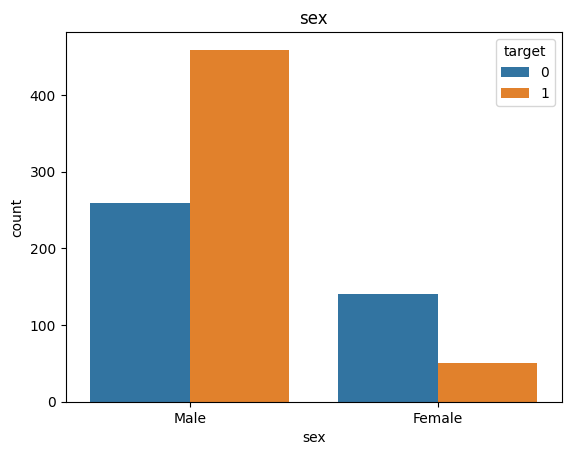

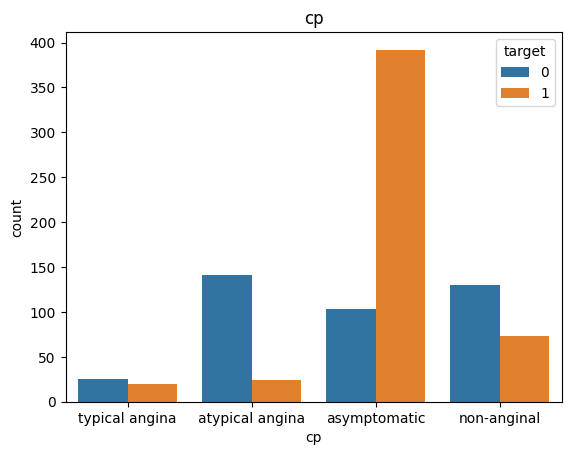

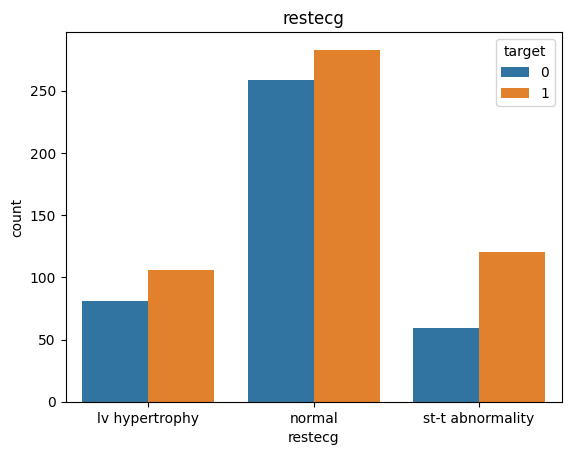

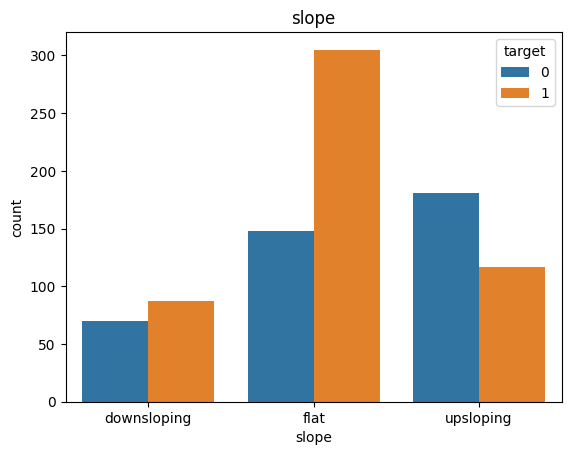

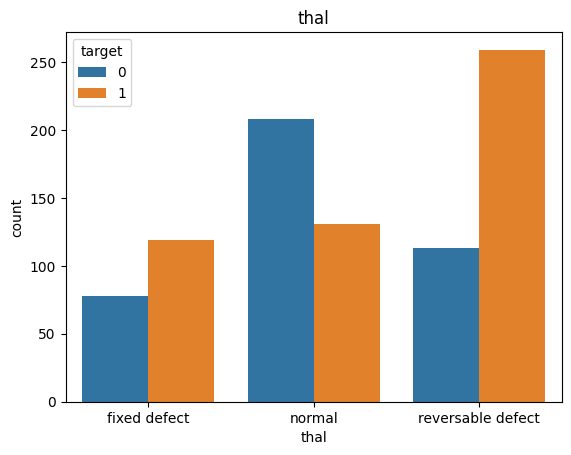

In [19]:
cat_cols = ["sex", "cp", "restecg", "slope", "thal"]
for col in cat_cols:
    plt.figure()
    sns.countplot(data=df, x=col, hue="target")
    plt.title(col)
    plt.show()

In [20]:
for col in num_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    df[col] = np.clip(df[col], lower, upper)

In [21]:
df["exang"] = df["exang"].astype(str).str.upper().str.replace("TURE", "TRUE")
df["exang"] = df["exang"].map({"TRUE": True, "FALSE": False})
df["oldpeak"] = df["oldpeak"].fillna(df["oldpeak"].median())

from sklearn.preprocessing import StandardScaler
ss = StandardScaler( )
df[num_cols] = ss.fit_transform(df[num_cols])

In [22]:
df_enc = pd.get_dummies(df.drop(columns=["num", "target"]), drop_first=True)
x = df_enc
y = df["target"]

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
x_tr, x_te, y_tr, y_te = train_test_split( x, y, test_size=0.2, random_state=42 )
clf = DecisionTreeClassifier( random_state=42 )
clf.fit( x_tr, y_tr )

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
preds = clf.predict( x_te )
print("Accuracy:", accuracy_score(y_te, preds))
print("Precision:", precision_score(y_te, preds))
print("Recall:", recall_score(y_te, preds))
print("F1:", f1_score(y_te, preds))
print("ROC AUC:", roc_auc_score(y_te, preds))

Accuracy: 0.7142857142857143
Precision: 0.7469879518072289
Recall: 0.6666666666666666
F1: 0.7045454545454546
ROC AUC: 0.7153558052434456


In [25]:
from sklearn.model_selection import GridSearchCV
params = {"max_depth": [3, 5, 7, None], "min_samples_split": [2, 5, 10], "criterion": ["gini", "entropy"]}
grid = GridSearchCV( DecisionTreeClassifier(random_state=42), params, cv=5 )
grid.fit( x_tr, y_tr )
print("Best Params:", grid.best_params_)
best_clf = grid.best_estimator_

Best Params: {'criterion': 'gini', 'max_depth': 7, 'min_samples_split': 10}


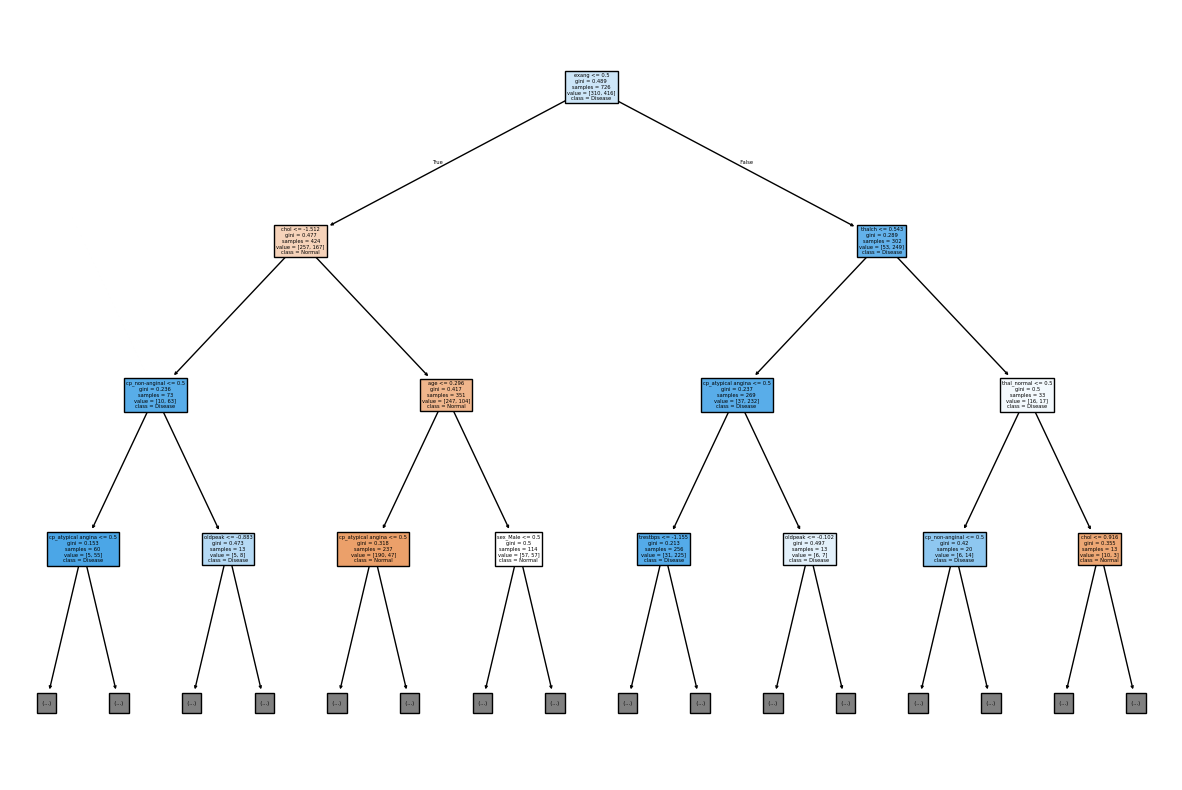

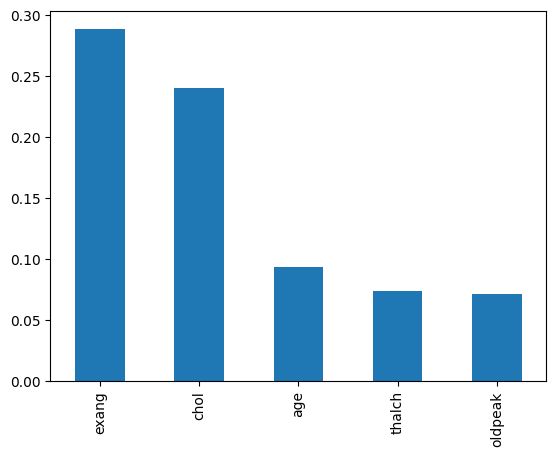

In [26]:
from sklearn.tree import plot_tree
plt.figure(figsize=(15, 10))
plot_tree(best_clf, max_depth=3, feature_names=x.columns, class_names=["Normal", "Disease"], filled=True)
plt.show()
feat_imp = pd.Series(best_clf.feature_importances_, index=x.columns).sort_values(ascending=False)
feat_imp.head(5).plot(kind="bar")
plt.show()

Common hyperparameters like max_depth set the tree height to control overfitting. Label encoding maps variables to integers which can imply numeric order, whereas One-Hot encoding converts classes into unique columns. 

In our model tuning max_depth=7 and min_samples_split=10 prevented the tree from growing infinitely, reducing overfitting and improving test accuracy compared to default unpruned settings.